# Chapter 6 - Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Faktafraga 1 - What is clustering? Give some examples of application areas.

*"Clustering means that data points are divided into different groups/clusters, where the principle is that data points that are similar to each other should end up in the same cluster."*

Clustering is an **unsupervised learning** technique: there is no target variable `y` telling the model the "correct" grouping - the model only sees `X` and has to discover structure in the data on its own (p. 233). The book contrasts this with classification: if a photo album had labels saying who is in each picture, sorting the pictures by person would be a (supervised) classification problem; without labels, grouping pictures of the same person together is an (unsupervised) clustering problem.

**Examples of application areas (Section 6.1.1, pp. 234-236):**

1. **Customer segmentation (kundsegmentering).** Customers who are similar with respect to variables such as purchasing behaviour, age and income level are grouped together (p. 234). A company can then adapt product offers and communication channels per segment - for example, a cluster dominated by retirees might prefer to be reached with physical mail, while a cluster of students might prefer social media ads (p. 234, Figure 6.1).
2. **Anomaly detection (anomalidetektion).** Clustering can be used to find observations, or entire clusters, that deviate from the rest of the data (p. 235-236, Figure 6.2). This is used, for example, by manufacturers to detect defective products on a production line, and by banks to flag unusual transactions that may need manual review for fraud.
3. **Semi-supervised learning (semi-vagledd inlarning).** When only a small subset of the training data has labels, clustering can be used first, and then labels can be assigned based on which cluster an observation belongs to (p. 236-237, and demonstrated fully in Kodexempel 2,

## Faktafraga 2 - Explain, in overview, how K-means works. Use Figure 6.3 (p. 238) and Figure 6.4 (p. 239) in your explanation.

**How K-means works, in overview (Section 6.2, p. 237 onward):**



*"The model is relatively simple: new data is grouped by assigning each data point to the cluster whose centroid is closest."*

Concretely: you choose a number of clusters `k` (the hyperparameter `n_clusters`, default 8, see Table 6.1, p. 241). The algorithm then places `k` centroids, assigns every observation to its nearest centroid, recomputes each centroid as the mean of the points assigned to it, and repeats this assignment/update cycle (Section 6.2.2, "Hur tranas modellen?", p. 243, Figure 6.7) until the centroids stop moving. Because it always groups points around the *nearest* centroid, K-means naturally tends to build round-ish (spherical) clusters of similar size.

**Using Figure 6.3 and Figure 6.4:**

Figure 6.3 (p. 238, "Visualisering av sanna klustertillhorigheter for simulerad data") shows four simulated datasets with their *true* cluster memberships: (1) three simple, well-separated round clusters, (2) elongated, non-spherical clusters, (3) clusters with clearly different variance/spread, and (4) clusters of very different sizes.

Figure 6.4 (p. 239, "Visualisering av hur K-means-modellen presterar pa datan simulerad fran Figur 6.3") then shows how K-means actually performs on each of those four datasets. The book's own commentary on the figure:

 *"In the top-left image we see that the result is poor because we specified the wrong number of clusters when training the model. In the top-right image the result is poor because the data does not have a spherical shape. In the bottom-left image the clusters are poor because the variance/spread of the data differs between the clusters. In the last image the clustering is poor because the cluster sizes differ."*

So together, Figures 6.3 and 6.4 illustrate both the mechanism (nearest-centroid assignment) and its key assumption: K-means works well mainly when clusters are **roughly spherical, similarly spread, and similarly sized** - and it degrades exactly when those assumptions are violated, or when `k` is chosen wrong.

Cluster centers found by K-means:
 [[-2.80037642  1.30082566]
 [ 0.20876306  2.25551336]
 [-1.46679593  2.28585348]
 [-2.79290307  2.79641063]
 [-2.80389616  1.80117999]]

Inertia (mean squared distance to nearest centroid): 211.59853725816842


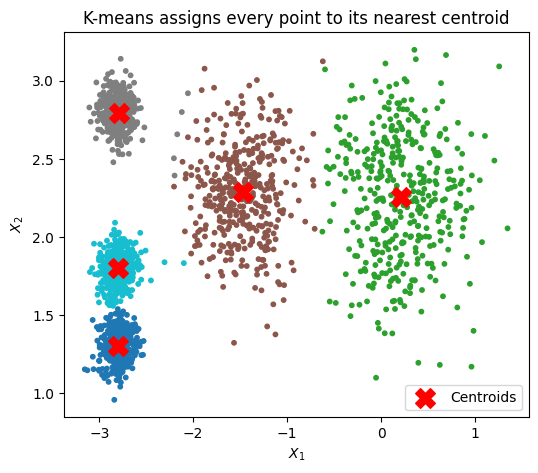

In [2]:
# Reproducing the book's own demonstration setup (Section 6.2.1, p. 241) to see
# the "assign -> recompute centroid -> repeat" mechanism described above in action.
blob_centers = np.array(
    [[0.2, 2.3],
     [-1.5, 2.3],
     [-2.8, 1.8],
     [-2.8, 2.8],
     [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X_demo, y_demo = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                             random_state=7)

kmeans_demo = KMeans(n_clusters=5, n_init=20, max_iter=400, random_state=RANDOM_STATE)
kmeans_demo.fit(X_demo)

print("Cluster centers found by K-means:\n", kmeans_demo.cluster_centers_)
print("\nInertia (mean squared distance to nearest centroid):", kmeans_demo.inertia_)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(X_demo[:, 0], X_demo[:, 1], c=kmeans_demo.labels_, cmap="tab10", s=10)
ax.scatter(kmeans_demo.cluster_centers_[:, 0], kmeans_demo.cluster_centers_[:, 1],
           c="red", marker="X", s=200, label="Centroids")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_title("K-means assigns every point to its nearest centroid")
ax.legend()
plt.show()


## Resonemangsfraga 3 - How can you choose the number of clusters for a K-means model? Use inertia, silhouette score and the silhouette diagram in your answer.

*"Since inertia is the mean squared distance between each observation and its nearest centroid, it will always decrease as the number of clusters increases. Therefore, simply choosing the model with the lowest inertia will always lead us to pick as many clusters as possible, which is not good."*

Instead, the book recommends plotting inertia against the number of clusters `k` and looking for an **"elbow"**: the point where the curve stops dropping sharply and starts flattening out (Figure 6.10, p. 247). Below `k`, adding a cluster still helps a lot; beyond it, adding more clusters barely reduces inertia further, so the elbow is a reasonable, if somewhat subjective, choice for `k`.

**Silhouette score (p. 248, Equation 6.1):**

Because reading an elbow "by eye" is a coarse heuristic, the book introduces a second, more precise metric: *silhouette score*, the average of every data point's silhouette coefficient,

$$SC = \frac{b - a}{\max(a, b)}$$

where *a* = the mean distance from a point to all other points in the **same** cluster (intra-cluster distance), and *b* = the mean distance to all points in the **nearest other** cluster (nearest-cluster distance) - see Figure 6.11 (p. 248). The silhouette coefficient always lies between -1 and +1: close to +1 means the point sits well inside its own cluster and far from other clusters; close to 0 means it sits near a cluster boundary; close to -1 means it was probably assigned to the wrong cluster. You compute the *silhouette score* for a few candidate values of `k` and pick the `k` with the highest score (Figure 6.12, p. 250 in the book plots this against `k`, similar to the elbow plot for inertia).

**Silhouette diagram (Figure 6.13, p. 251):**

The silhouette score is a single average number per `k`, which can hide problems (e.g. one huge good cluster and one tiny bad cluster can still average out to a decent score). The *silhouette diagram* plots, for a given `k`, one "knife" shape per cluster: the knife's height is the number of observations in that cluster, and its width at each point is that observation's own silhouette coefficient, sorted from lowest to highest. A dashed vertical line marks the overall average (the silhouette score). A cluster is considered good when most of its knife extends **past** the dashed line; if most of a cluster's observations fall short of the dashed line, that cluster is probably poorly separated from a neighbour (p. 250-251).

**Putting it together:** in practice you would compute inertia and silhouette score for a range of `k` values, look at both curves for a candidate elbow/peak, then check the silhouette diagram at that `k` (and its close neighbours) to also confirm the clusters are reasonably balanced in size, before making a final, partly subjective, choice.

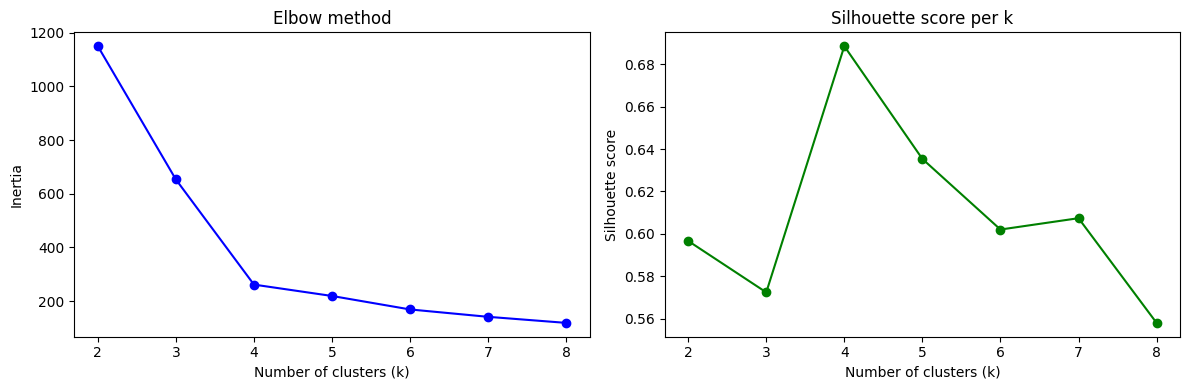

k values:  [2, 3, 4, 5, 6, 7, 8]
Inertia:   [1149.6, 653.2, 261.8, 219.4, 169.3, 141.8, 119.2]
Silhouette: [0.5966, 0.5724, 0.6885, 0.6353, 0.602, 0.6074, 0.558]

Best k by silhouette score: 4 -- note this dataset was simulated with 5 true clusters, so even here the
silhouette-maximising k does not perfectly recover the true number of groups,
which is exactly the 'not an exact science' point from Questions 4 and 5.


In [3]:
# A concrete demonstration on the same synthetic blob dataset as above.
k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_demo)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_demo, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, "bo-")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), sil_scores, "go-")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score per k")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("k values: ", list(k_range))
print("Inertia:  ", [round(i, 1) for i in inertias])
print("Silhouette:", [round(s, 4) for s in sil_scores])
print("\nBest k by silhouette score:", best_k,
      "-- note this dataset was simulated with 5 true clusters, so even here the")
print("silhouette-maximising k does not perfectly recover the true number of groups,")
print("which is exactly the 'not an exact science' point from Questions 4 and 5.")


## Resonemangsfraga 4 - Looking at Figure 6.10 on page 247, how many clusters would you have chosen and why? Is choosing the number of clusters an "exact science"?

Figure 6.10 plots inertia against the number of clusters (1 through 9) for the book's example dataset (the one shown un-clustered in Figure 6.5, p. 240). Reading the curve: inertia drops steeply from `k=1` to `k=4`, and then the slope becomes much shallower from `k=4` onward - the curve gets an "elbow"-like shape right at `k=4` (the book marks this point directly on the figure with an arrow labelled "Armbage", i.e. "Elbow").

**I would choose k = 4** for this reason: up to 4 clusters, each additional cluster buys a large reduction in inertia (meaning points get noticeably closer to their centroids), but from 4 clusters onward the curve flattens - clusters 5, 6, 7, 8 and 9 only shave off a small, diminishing amount of extra inertia each time. Since using more clusters than necessary would only add complexity without much benefit to how tightly the data is grouped, the elbow at `k=4` is the point of best trade-off. This matches the book's own reading of the same figure:

*"There we can clearly see that inertia decreases quickly up to four clusters, and then declines more slowly. The curve gets an 'elbow-like' shape after four clusters. In this case it would therefore be reasonable to choose four clusters."*

**Is it an exact science? No.** The book is explicit about this a few pages later, after also bringing in the silhouette score and silhouette diagram for the very same dataset:

 *"Even though the silhouette score is lower when we use five clusters, it is a reasonable choice to make since the cluster sizes are similar, which is generally desirable when using the K-means model. We therefore choose to use five clusters in this case. In practice we could just as well have chosen three or four - so it is not an exact science, and we need to use our judgement."*

So even though the elbow chart alone points to `k=4`, the book's own final choice (once silhouette score and the silhouette diagram are also taken into account) ends up being `k=5`, and the authors explicitly say three or four would also have been defensible. Choosing the number of clusters is therefore a judgement call informed by several diagnostics together, not a single formula with one correct answer.

## Resonemangsfraga 5 - How do you interpret Figure 6.13 on page 251?

Figure 6.13 shows four silhouette diagrams side by side, for `k = 3, 4, 5` and `k = 6`, all computed on the same dataset used throughout Section 6.2.3. As explained under Question 3 above, each diagram contains one "knife" per cluster: the knife's **height** is the number of observations in that cluster, and its **width**, read left-to-right, is that cluster's silhouette coefficients sorted from lowest to highest (so a wider knife = better-separated points). The dashed red vertical line in each panel marks that `k`'s overall silhouette score (the average across all points).

Reading the four panels, per the book's own commentary (p. 251):

- **k = 3 and k = 4:** in both cases, one particular cluster (the one with index 1) is much larger than the others - a very tall knife. The book notes this directly: *"Vi ser att nar vi valjer tre kluster (k=3) sa blir det klustret med index 1 (den andra kniven) valdigt stort. Det sker aven i det fall vi har fyra kluster (k=4)."* (Translated: *"We see that when we choose three clusters (k=3), the cluster with index 1 (the second knife) becomes very large. This also happens when we have four clusters (k=4)."*) An oversized cluster like this suggests that cluster may really contain more internal sub-structure that a single cluster is glossing over.
- **k = 5:** the five knives are much more even in height (i.e. the cluster sizes are more balanced), even though the average silhouette score for k=5 is slightly lower than for k=4 (compare with Figure 6.12, p. 250).
- **k = 6:** this is the worst panel. The book states: *"Om vi kollar pa Figur 6.13 ser vi att nar vi har sex (k=6) kluster sa blir resultatet samre an i ovriga fall, silhouette score ar lagre och alla knivarna passerar inte den streckade linjen."* (Translated: *"If we look at Figure 6.13 we see that when we have six (k=6) clusters, the result is worse than in the other cases - the silhouette score is lower and not all the knives pass the dashed line."*) Knives that fail to reach the dashed line indicate clusters whose points are, on average, not well separated from a neighbouring cluster.

**Overall interpretation:** despite k=4 technically scoring a hair higher on silhouette score than k=5, the book chooses **k=5** as the final answer, because it produces more evenly-sized, better-balanced clusters overall - again illustrating Question 4's point that this choice takes judgement, not just picking whichever single number is mathematically highest.